# Machine Learning-Based Passive Beamforming Optimization for RIS-Assisted Wireless Communication

This notebook develops an end-to-end SISO RIS system model and trains a neural network to predict discrete 2-bit RIS phase configurations from the cascaded BS-RIS-user channel.

The final evaluation compares random RIS, quantized analytical phase selection, coordinate descent, and the proposed cascaded-channel ML model.


## 1. Problem Definition

We consider a narrowband, quasi-static SISO communication link:

**BS → RIS → User**

The RIS contains `N` passive reflecting elements. Each element applies a discrete 2-bit phase shift:

\[
\mathcal{F} = \left\{0,rac{\pi}{2},\pi,rac{3\pi}{2}ight\}.
\]

For RIS element \(n\), the cascaded channel is

\[
c_n = h_{BR,n}h_{RU,n}.
\]

The effective channel is

\[
h_{\mathrm{eff}} =
\sum_{n=1}^{N} c_n e^{j	heta_n}.
\]

The received SNR is

\[
\mathrm{SNR} =
rac{P|h_{\mathrm{eff}}|^2}{\sigma^2},
\]

and the achievable rate is

\[
R = \log_2(1+\mathrm{SNR}).
\]

The ML task is to learn the mapping

\[
\{c_n\}_{n=1}^{N}
ightarrow
\{	heta_n\}_{n=1}^{N}.
\]


## 2. Imports and System Parameters

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

N = 16
P = 1.0
noise_power = 1.0
num_realizations = 1000

phase_levels = np.array([
    0,
    np.pi / 2,
    np.pi,
    3 * np.pi / 2
])

print("RIS elements:", N)
print("Phase levels:", phase_levels)
print("Monte Carlo realizations:", num_realizations)


RIS elements: 16
Phase levels: [0.         1.57079633 3.14159265 4.71238898]
Monte Carlo realizations: 1000


## 3. RIS Channel Model

In [2]:
h_BR = (
    np.random.randn(N) + 1j * np.random.randn(N)
) / np.sqrt(2)

h_RU = (
    np.random.randn(N) + 1j * np.random.randn(N)
) / np.sqrt(2)

cascaded_channel = h_BR * h_RU

print("h_BR shape:", h_BR.shape)
print("h_RU shape:", h_RU.shape)
print("Cascaded channel shape:", cascaded_channel.shape)


h_BR shape: (16,)
h_RU shape: (16,)
Cascaded channel shape: (16,)


## 4. Random and Continuous-Phase RIS

In [3]:
random_phases = np.random.uniform(
    0,
    2 * np.pi,
    N
)

phi_random = np.exp(1j * random_phases)

h_eff_random = np.sum(
    cascaded_channel * phi_random
)

snr_random = (
    P * np.abs(h_eff_random) ** 2
    / noise_power
)

rate_random = np.log2(1 + snr_random)

continuous_phases = -np.angle(cascaded_channel)
phi_continuous = np.exp(1j * continuous_phases)

h_eff_continuous = np.sum(
    cascaded_channel * phi_continuous
)

snr_continuous = (
    P * np.abs(h_eff_continuous) ** 2
    / noise_power
)

rate_continuous = np.log2(1 + snr_continuous)

print("Random RIS SNR:", 10 * np.log10(snr_random), "dB")
print("Continuous-phase RIS SNR:", 10 * np.log10(snr_continuous), "dB")
print("Continuous-phase RIS rate:", rate_continuous, "bits/s/Hz")


Random RIS SNR: 4.075134064903011 dB
Continuous-phase RIS SNR: 20.183214551175354 dB
Continuous-phase RIS rate: 6.7184838529475845 bits/s/Hz


## 5. Monte Carlo RIS Performance

In [4]:
snr_random_all = []
snr_continuous_all = []
rate_random_all = []
rate_continuous_all = []

for _ in range(num_realizations):
    h_BR_mc = (
        np.random.randn(N) + 1j * np.random.randn(N)
    ) / np.sqrt(2)

    h_RU_mc = (
        np.random.randn(N) + 1j * np.random.randn(N)
    ) / np.sqrt(2)

    cascaded_channel_mc = h_BR_mc * h_RU_mc

    random_phases = np.random.uniform(
        0,
        2 * np.pi,
        N
    )

    h_eff_random = np.sum(
        cascaded_channel_mc * np.exp(1j * random_phases)
    )

    optimal_phases = -np.angle(cascaded_channel_mc)

    h_eff_continuous = np.sum(
        cascaded_channel_mc * np.exp(1j * optimal_phases)
    )

    snr_random = (
        P * np.abs(h_eff_random) ** 2
        / noise_power
    )

    snr_continuous = (
        P * np.abs(h_eff_continuous) ** 2
        / noise_power
    )

    snr_random_all.append(snr_random)
    snr_continuous_all.append(snr_continuous)

    rate_random_all.append(np.log2(1 + snr_random))
    rate_continuous_all.append(np.log2(1 + snr_continuous))

snr_random_all = np.array(snr_random_all)
snr_continuous_all = np.array(snr_continuous_all)
rate_random_all = np.array(rate_random_all)
rate_continuous_all = np.array(rate_continuous_all)

print(
    "Average random RIS SNR:",
    np.mean(10 * np.log10(snr_random_all)),
    "dB"
)

print(
    "Average continuous-phase RIS SNR:",
    np.mean(10 * np.log10(snr_continuous_all)),
    "dB"
)


Average random RIS SNR: 9.262140481572606 dB
Average continuous-phase RIS SNR: 21.888440445238803 dB


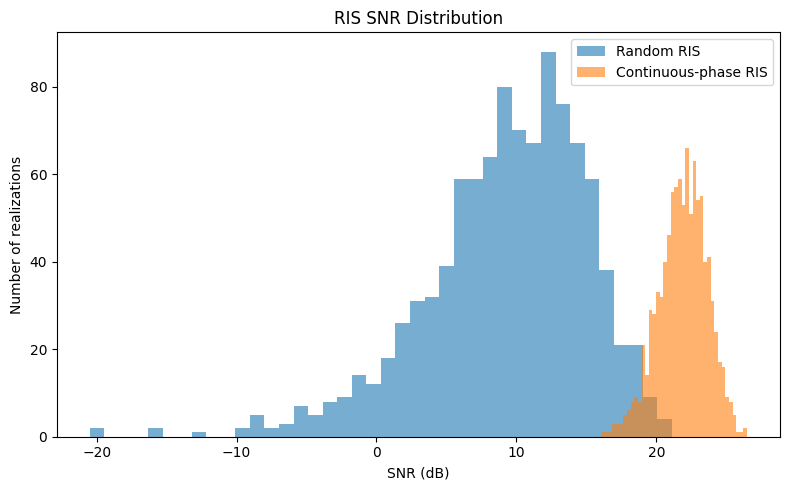

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    10 * np.log10(snr_random_all),
    bins=40,
    alpha=0.6,
    label="Random RIS"
)

plt.hist(
    10 * np.log10(snr_continuous_all),
    bins=40,
    alpha=0.6,
    label="Continuous-phase RIS"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Number of realizations")
plt.title("RIS SNR Distribution")
plt.legend()
plt.tight_layout()
plt.show()


## 6. 2-bit RIS Phase Quantization

In [6]:
def quantize_phase(phase, phase_levels):
    phase = np.mod(phase, 2 * np.pi)

    differences = np.abs(
        np.angle(
            np.exp(1j * (phase - phase_levels))
        )
    )

    return phase_levels[np.argmin(differences)]


In [7]:
quantized_phases = np.array([
    quantize_phase(
        phase,
        phase_levels
    )
    for phase in continuous_phases
])

phi_quantized = np.exp(1j * quantized_phases)

h_eff_quantized = np.sum(
    cascaded_channel * phi_quantized
)

snr_quantized = (
    P * np.abs(h_eff_quantized) ** 2
    / noise_power
)

rate_quantized = np.log2(1 + snr_quantized)

print(
    "Continuous-phase SNR:",
    10 * np.log10(snr_continuous),
    "dB"
)

print(
    "Quantized 2-bit SNR:",
    10 * np.log10(snr_quantized),
    "dB"
)

print(
    "Quantized 2-bit rate:",
    rate_quantized,
    "bits/s/Hz"
)


Continuous-phase SNR: 23.63129581150632 dB
Quantized 2-bit SNR: 19.324007136787085 dB
Quantized 2-bit rate: 6.436055252104124 bits/s/Hz


## 7. ML Dataset Generation

The phase decision is directly determined by the cascaded channel. Therefore, the final ML formulation uses

\[
X =
[\Re\{c_1,\ldots,c_N\},
\Im\{c_1,\ldots,c_N\}]
\]

as the input.

The target for each RIS element is the nearest 2-bit phase state to the continuous-phase solution

\[
	heta_n^*=-ngle(c_n).
\]

The four phase states are represented by class labels `0, 1, 2, 3`.


In [8]:
N_ml = 16
num_samples = 10000

cascaded_dataset = np.zeros(
    (num_samples, N_ml),
    dtype=np.complex128
)

Y_classes = np.zeros(
    (num_samples, N_ml),
    dtype=int
)

for sample in range(num_samples):
    h_BR = (
        np.random.randn(N_ml)
        + 1j * np.random.randn(N_ml)
    ) / np.sqrt(2)

    h_RU = (
        np.random.randn(N_ml)
        + 1j * np.random.randn(N_ml)
    ) / np.sqrt(2)

    cascaded = h_BR * h_RU

    continuous_phase = -np.angle(cascaded)

    phase_difference = np.angle(
        np.exp(
            1j * (
                continuous_phase[:, None]
                - phase_levels[None, :]
            )
        )
    )

    class_indices = np.argmin(
        np.abs(phase_difference),
        axis=1
    )

    cascaded_dataset[sample] = cascaded
    Y_classes[sample] = class_indices

X_cascaded = np.hstack([
    np.real(cascaded_dataset),
    np.imag(cascaded_dataset)
])

print("Feature matrix shape:", X_cascaded.shape)
print("Target matrix shape:", Y_classes.shape)


Feature matrix shape: (10000, 32)
Target matrix shape: (10000, 16)


## 8. Train/Test Split and Feature Scaling

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_cascaded,
    Y_classes,
    test_size=0.20,
    random_state=42
)

cascaded_scaler = StandardScaler()

X_train_scaled = cascaded_scaler.fit_transform(
    X_train
)

X_test_scaled = cascaded_scaler.transform(
    X_test
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Training feature shape:", X_train_scaled.shape)
print("Test feature shape:", X_test_scaled.shape)


Training samples: 8000
Test samples: 2000
Training feature shape: (8000, 32)
Test feature shape: (2000, 32)


## 9. Reconstruct Complex Cascaded Channels

In [10]:
cascaded_train = (
    X_train[:, :N_ml]
    + 1j * X_train[:, N_ml:]
)

cascaded_test = (
    X_test[:, :N_ml]
    + 1j * X_test[:, N_ml:]
)

continuous_phase_test = -np.angle(
    cascaded_test
)

phase_difference_test = np.angle(
    np.exp(
        1j * (
            continuous_phase_test[:, :, None]
            - phase_levels[None, None, :]
        )
    )
)

Y_test_analytical = np.argmin(
    np.abs(phase_difference_test),
    axis=2
)

continuous_phase_train = -np.angle(
    cascaded_train
)

phase_difference_train = np.angle(
    np.exp(
        1j * (
            continuous_phase_train[:, :, None]
            - phase_levels[None, None, :]
        )
    )
)

Y_train_analytical = np.argmin(
    np.abs(phase_difference_train),
    axis=2
)

print("Cascaded training shape:", cascaded_train.shape)
print("Cascaded test shape:", cascaded_test.shape)


Cascaded training shape: (8000, 16)
Cascaded test shape: (2000, 16)


## 10. Coordinate Descent Reference

In [11]:
def optimize_ris_coordinate_descent(
    cascaded_channel,
    phase_levels,
    num_iterations=3
):
    num_elements = len(cascaded_channel)
    phases = np.zeros(num_elements)

    for _ in range(num_iterations):
        for n in range(num_elements):
            best_phase = phases[n]
            best_gain = -np.inf

            for candidate_phase in phase_levels:
                test_phases = phases.copy()
                test_phases[n] = candidate_phase

                phi = np.exp(1j * test_phases)

                effective_channel = np.sum(
                    cascaded_channel * phi
                )

                gain = np.abs(
                    effective_channel
                ) ** 2

                if gain > best_gain:
                    best_gain = gain
                    best_phase = candidate_phase

            phases[n] = best_phase

    return phases


In [12]:
coordinate_phases_test = np.zeros(
    (len(cascaded_test), N_ml)
)

for i in range(len(cascaded_test)):
    coordinate_phases_test[i] = (
        optimize_ris_coordinate_descent(
            cascaded_test[i],
            phase_levels,
            num_iterations=3
        )
    )

phi_coordinate = np.exp(
    1j * coordinate_phases_test
)

h_eff_coordinate = np.sum(
    cascaded_test * phi_coordinate,
    axis=1
)

snr_coordinate = (
    P * np.abs(h_eff_coordinate) ** 2
    / noise_power
)

rate_coordinate = np.log2(
    1 + snr_coordinate
)

print(
    "Coordinate descent average SNR:",
    np.mean(10 * np.log10(snr_coordinate)),
    "dB"
)


Coordinate descent average SNR: 21.20838313984195 dB


## 11. ML Model Architecture

In [13]:
class RISMultiHeadNetwork(nn.Module):
    def __init__(
        self,
        input_size,
        num_elements,
        num_phases
    ):
        super().__init__()

        self.shared_network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.phase_heads = nn.ModuleList([
            nn.Linear(64, num_phases)
            for _ in range(num_elements)
        ])

    def forward(self, x):
        shared_features = self.shared_network(x)

        outputs = [
            head(shared_features)
            for head in self.phase_heads
        ]

        return torch.stack(
            outputs,
            dim=1
        )


## 12. Train the Cascaded-Channel ML Model

Each RIS element has its own four-class output head. Cross-entropy loss is applied across the phase decision of every RIS element.


In [14]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train_analytical,
    dtype=torch.long
)

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

analytical_ml_model = RISMultiHeadNetwork(
    input_size=2 * N_ml,
    num_elements=N_ml,
    num_phases=len(phase_levels)
)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    analytical_ml_model.parameters(),
    lr=0.001
)

num_epochs = 30
training_losses = []


In [15]:
for epoch in range(num_epochs):
    analytical_ml_model.train()

    running_loss = 0.0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()

        outputs = analytical_ml_model(
            X_batch
        )

        loss = sum(
            criterion(
                outputs[:, n, :],
                Y_batch[:, n]
            )
            for n in range(N_ml)
        ) / N_ml

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss
        / len(train_loader)
    )

    training_losses.append(
        epoch_loss
    )

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/{num_epochs}, "
            f"Loss: {epoch_loss:.4f}"
        )


Epoch 5/30, Loss: 0.7713


Epoch 10/30, Loss: 0.4005


Epoch 15/30, Loss: 0.2991


Epoch 20/30, Loss: 0.2465


Epoch 25/30, Loss: 0.2196


Epoch 30/30, Loss: 0.1979


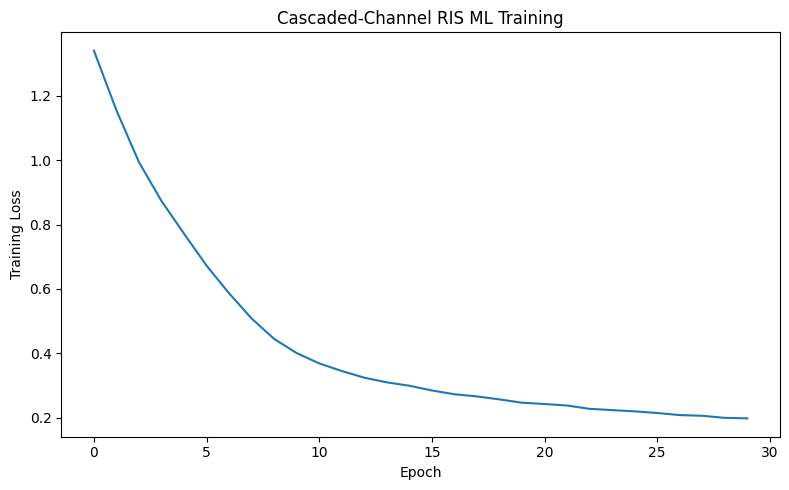

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(training_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Cascaded-Channel RIS ML Training")

plt.tight_layout()
plt.show()


## 13. RIS Phase Prediction and Classification Accuracy

In [17]:
analytical_ml_model.eval()
with torch.no_grad():
    outputs = analytical_ml_model(X_test_tensor)
Y_pred_ml = torch.argmax(outputs, dim=2).numpy()
analytical_ml_accuracy = accuracy_score(Y_test_analytical.reshape(-1), Y_pred_ml.reshape(-1))
wrong_elements = np.sum(Y_test_analytical != Y_pred_ml, axis=1)
print("ML element-wise accuracy:", analytical_ml_accuracy)
print("Average incorrect RIS elements:", np.mean(wrong_elements))
print("Maximum incorrect RIS elements:", np.max(wrong_elements))


ML element-wise accuracy: 0.88634375
Average incorrect RIS elements: 1.8185
Maximum incorrect RIS elements: 7


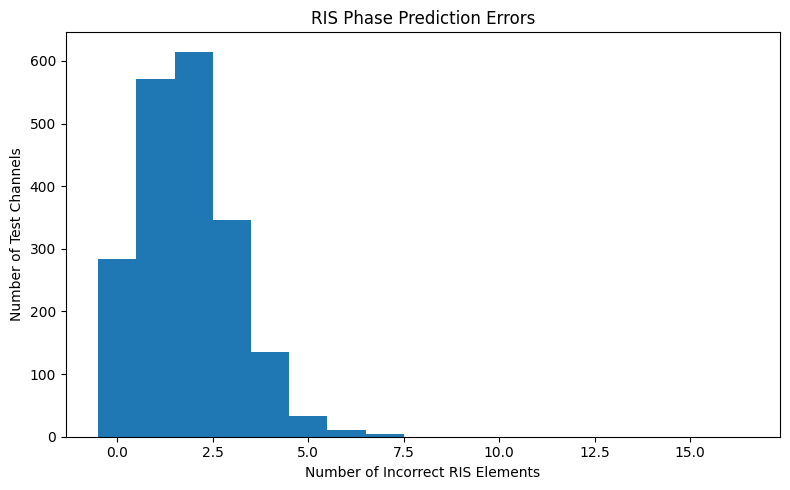

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(wrong_elements, bins=np.arange(-0.5, N_ml + 1.5, 1))
plt.xlabel("Number of Incorrect RIS Elements")
plt.ylabel("Number of Test Channels")
plt.title("RIS Phase Prediction Errors")
plt.tight_layout()
plt.show()


## 14. Communication Performance Evaluation


In [19]:
predicted_phases = phase_levels[Y_pred_ml]
phi_ml = np.exp(1j * predicted_phases)
h_eff_ml = np.sum(cascaded_test * phi_ml, axis=1)
snr_ml = P * np.abs(h_eff_ml) ** 2 / noise_power
rate_ml = np.log2(1 + snr_ml)

analytical_phases_test = phase_levels[Y_test_analytical]
phi_analytical = np.exp(1j * analytical_phases_test)
h_eff_analytical = np.sum(cascaded_test * phi_analytical, axis=1)
snr_analytical = P * np.abs(h_eff_analytical) ** 2 / noise_power
rate_analytical = np.log2(1 + snr_analytical)

rng = np.random.default_rng(42)
random_phases_test = rng.uniform(0, 2 * np.pi, size=(len(cascaded_test), N_ml))
phi_random_test = np.exp(1j * random_phases_test)
h_eff_random_test = np.sum(cascaded_test * phi_random_test, axis=1)
snr_random_test = P * np.abs(h_eff_random_test) ** 2 / noise_power
rate_random_test = np.log2(1 + snr_random_test)


## 15. Final Method Comparison


In [20]:
final_results = pd.DataFrame({
    "Method": ["Random RIS", "Quantized Analytical RIS", "Coordinate Descent RIS", "Cascaded-Channel ML RIS"],
    "Average_SNR_dB": [np.mean(10*np.log10(snr_random_test)), np.mean(10*np.log10(snr_analytical)), np.mean(10*np.log10(snr_coordinate)), np.mean(10*np.log10(snr_ml))],
    "Average_Rate_bits_per_Hz": [np.mean(rate_random_test), np.mean(rate_analytical), np.mean(rate_coordinate), np.mean(rate_ml)]
})
final_results


,Method,Average_SNR_dB,Average_Rate_bits_per_Hz
0,Random RIS,9.237257,3.384205
1,Quantized Analytical RIS,21.001869,6.989082
2,Coordinate Descent RIS,21.208383,7.057081
3,Cascaded-Channel ML RIS,20.897866,6.954827


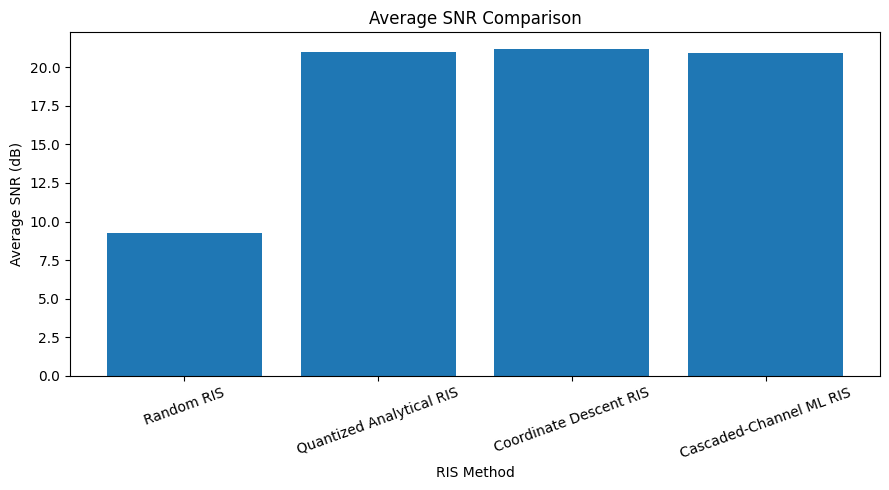

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(final_results["Method"], final_results["Average_SNR_dB"])
plt.ylabel("Average SNR (dB)")
plt.xlabel("RIS Method")
plt.title("Average SNR Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


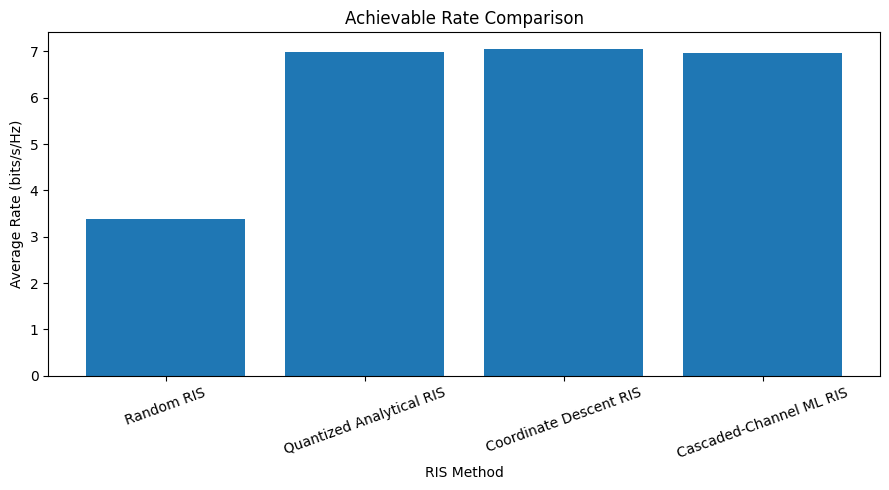

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(final_results["Method"], final_results["Average_Rate_bits_per_Hz"])
plt.ylabel("Average Rate (bits/s/Hz)")
plt.xlabel("RIS Method")
plt.title("Achievable Rate Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 16. ML Performance Metrics


In [23]:
analytical_snr_db = np.mean(10*np.log10(snr_analytical))
ml_snr_db = np.mean(10*np.log10(snr_ml))
analytical_rate = np.mean(rate_analytical)
ml_rate = np.mean(rate_ml)
snr_gap = analytical_snr_db - ml_snr_db
rate_gap = analytical_rate - ml_rate
snr_retention = np.mean(snr_ml) / np.mean(snr_analytical) * 100
rate_retention = ml_rate / analytical_rate * 100
ml_metrics = pd.DataFrame({
    "Metric": ["Element-wise phase accuracy", "SNR gap vs analytical", "Rate gap vs analytical", "SNR retention", "Rate retention"],
    "Value": [analytical_ml_accuracy*100, snr_gap, rate_gap, snr_retention, rate_retention],
    "Unit": ["%", "dB", "bits/s/Hz", "%", "%"]
})
ml_metrics


,Metric,Value,Unit
0,Element-wise phase accuracy,88.634375,%
1,SNR gap vs analytical,0.104003,dB
2,Rate gap vs analytical,0.034255,bits/s/Hz
3,SNR retention,97.609960,%
4,Rate retention,99.509878,%


## 17. Inference Timing


In [24]:
analytical_ml_model.eval()
start_time = time.perf_counter()
with torch.no_grad():
    _ = analytical_ml_model(X_test_tensor)
ml_inference_time = time.perf_counter() - start_time
ml_time_per_channel = ml_inference_time / len(X_test_tensor)
start_time = time.perf_counter()
continuous_phase_test = -np.angle(cascaded_test)
phase_difference = np.angle(np.exp(1j*(continuous_phase_test[:, :, None] - phase_levels[None, None, :])))
_ = np.argmin(np.abs(phase_difference), axis=2)
analytical_time = time.perf_counter() - start_time
analytical_time_per_channel = analytical_time / len(cascaded_test)
timing_results = pd.DataFrame({"Method":["ML inference","Analytical phase selection"],"Total_Time_seconds":[ml_inference_time,analytical_time],"Time_per_Channel_seconds":[ml_time_per_channel,analytical_time_per_channel]})
timing_results


,Method,Total_Time_seconds,Time_per_Channel_seconds
0,ML inference,0.003195,0.000002
1,Analytical phase selection,0.007519,0.000004


## 18. Save Final Model Artifacts


In [25]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
models_dir = project_root / "models"
results_dir = project_root / "results"
models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "ris_phase_predictor.pth"
scaler_path = models_dir / "cascaded_channel_scaler.pkl"
config_path = models_dir / "model_config.json"
torch.save(analytical_ml_model.state_dict(), model_path)
import joblib
joblib.dump(cascaded_scaler, scaler_path)
model_config = {"num_ris_elements":N_ml,"num_phase_levels":len(phase_levels),"phase_levels":phase_levels.tolist(),"input_features":2*N_ml,"hidden_layers":[256,128,64],"learning_rate":0.001,"batch_size":256,"num_epochs":num_epochs,"random_seed":42}
with open(config_path,"w") as file: json.dump(model_config,file,indent=4)
print("Model saved to:", model_path)
print("Scaler saved to:", scaler_path)
print("Configuration saved to:", config_path)


Model saved to: /models/ris_phase_predictor.pth
Scaler saved to: /models/cascaded_channel_scaler.pkl
Configuration saved to: /models/model_config.json


## 19. Save Results


In [26]:
final_results.to_csv(results_dir / "final_method_comparison.csv", index=False)
ml_metrics.to_csv(results_dir / "ml_performance_metrics.csv", index=False)
timing_results.to_csv(results_dir / "inference_timing.csv", index=False)
print("Final result files saved to:", results_dir)


Final result files saved to: /results


## 20. Conclusion

The final ML system learns the mapping from the cascaded BS-RIS-user channel to a discrete 2-bit RIS phase configuration. The evaluation uses phase prediction accuracy and communication metrics, including average SNR, achievable rate, SNR gap, rate retention, and inference time.

The coordinate-descent solution is used as a reference optimization method. The ML model is not claimed to outperform optimization; its purpose is to approximate the analytical phase-selection mapping while retaining communication performance.

**The cascaded-channel ML model learns discrete RIS phase selection and preserves nearly all of the achievable-rate performance of the quantized analytical reference.**
